In [17]:
from bs4 import BeautifulSoup

In [ ]:
import requests

url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.text)

In [19]:
obj=BeautifulSoup(response.text,'lxml')

In [ ]:
obj

In [21]:
obj.find('a').text

'Books to Scrape'

In [22]:
 #Print the first five book titles
print("First Five Book Titles:\n")

for book in books[:5]:
    title = book.h3.a["title"]
    print(title)

First Five Book Titles:

Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Princess Jellyfish 2-in-1 Omnibus #1)
Princess Between Worlds (Wide-Awake Princess #5)
Pop Gun War, Volume 1: Gift
Political Suicide: Missteps, Peccadilloes, Bad Calls, Backroom Hijinx, Sordid Pasts, Rotten Breaks, and Just Plain Dumb Mistakes in the Annals of American Politics
Patience


In [23]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re

url = "http://books.toscrape.com/"

response = requests.get(url)
response.encoding = "utf-8"

soup = BeautifulSoup(response.text, "html.parser")

print("Website Title:")
print(soup.title.text)

books = soup.find_all("article", class_="product_pod")
books

Website Title:

    All products | Books to Scrape - Sandbox



[<article class="product_pod">
 <div class="image_container">
 <a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
 </div>
 <p class="star-rating Three">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>
 <h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
 <div class="product_price">
 <p class="price_color">£51.77</p>
 <p class="instock availability">
 <i class="icon-ok"></i>
     
         In stock
     
 </p>
 <form>
 <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
 </form>
 </div>
 </article>,
 <article class="product_pod">
 <div class="image_container">
 <a href="catalogue/tipping-the-velvet_999/index.html"><img alt="Tipping the Velvet" class="thu

In [24]:


print("\nTotal Books on First Page:", len(books))

print("\nFirst Five Book Titles")

for book in books[:5]:
    print(book.h3.a["title"])

data = []

for book in books:

    title = book.h3.a["title"]

    price = book.find("p", class_="price_color").text
    price = float(re.sub(r"[^\d.]", "", price))

    rating = book.find("p")["class"][1]

    availability = book.find("p", class_="instock availability").text.strip()

    data.append([title, price, rating, availability])


Total Books on First Page: 20

First Five Book Titles
A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind



First 10 Records
                                               Title  Price Rating  \
0                               A Light in the Attic  51.77  Three   
1                                 Tipping the Velvet  53.74    One   
2                                         Soumission  50.10    One   
3                                      Sharp Objects  47.82   Four   
4              Sapiens: A Brief History of Humankind  54.23   Five   
5                                    The Requiem Red  22.65    One   
6  The Dirty Little Secrets of Getting Your Dream...  33.34   Four   
7  The Coming Woman: A Novel Based on the Life of...  17.93  Three   
8  The Boys in the Boat: Nine Americans and Their...  22.60   Four   
9                                    The Black Maria  52.15    One   

  Availability  
0     In stock  
1     In stock  
2     In stock  
3     In stock  
4     In stock  
5     In stock  
6     In stock  
7     In stock  
8     In stock  
9     In stock  

books.csv saved success

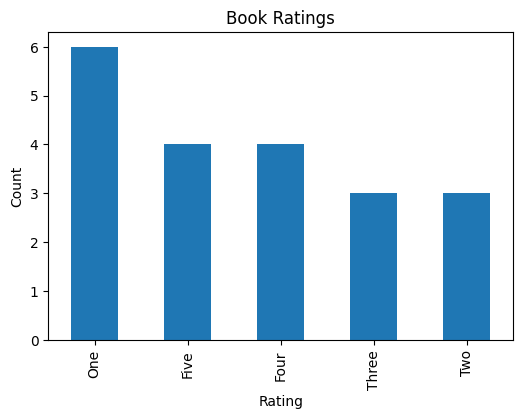

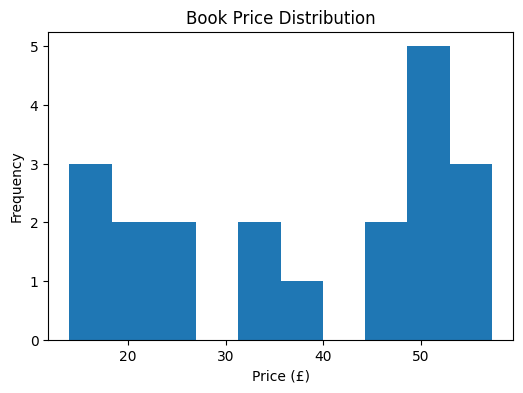


books_100.csv saved successfully!

Most Common Rating:
One

Highest-Priced Book:
Title           The Death of Humanity: and the Case for Life
Price                                                  58.11
Rating                                                  Four
Availability                                        In stock
Name: 68, dtype: object

Lowest-Priced Book:
Title           Patience
Price              10.16
Rating             Three
Availability    In stock
Name: 84, dtype: object

Top 10 Most Expensive Books:
                                                Title  Price Rating  \
68       The Death of Humanity: and the Case for Life  58.11   Four   
40                     Slow States of Collapse: Poems  57.31  Three   
15  Our Band Could Be Your Life: Scenes from the A...  57.25  Three   
58                                The Past Never Ends  56.50   Four   
57  The Pioneer Woman Cooks: Dinnertime: Comfort C...  56.41    One   
91                                  Masks and Sha

In [25]:


df = pd.DataFrame(
    data,
    columns=["Title", "Price", "Rating", "Availability"]
)

print("\nFirst 10 Records")
print(df.head(10))

df.to_csv("books.csv", index=False)

print("\nbooks.csv saved successfully!")

print("\nTotal Books:", len(df))

print("Average Price:", round(df["Price"].mean(), 2))

print("\nBooks in Each Rating")
print(df["Rating"].value_counts())

print("\nBooks Currently in Stock")
print((df["Availability"] == "In stock").sum())

plt.figure(figsize=(6, 4))
df["Rating"].value_counts().plot(kind="bar")
plt.title("Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["Price"], bins=10)
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

all_books = []

for page in range(1, 6):

    if page == 1:
        page_url = "http://books.toscrape.com/"
    else:
        page_url = f"http://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(page_url)
    response.encoding = "utf-8"

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:

        title = book.h3.a["title"]

        price = book.find("p", class_="price_color").text
        price = float(re.sub(r"[^\d.]", "", price))

        rating = book.find("p")["class"][1]

        availability = book.find("p", class_="instock availability").text.strip()

        all_books.append([title, price, rating, availability])

books100 = pd.DataFrame(
    all_books,
    columns=["Title", "Price", "Rating", "Availability"]
)

books100.to_csv("books_100.csv", index=False)

print("\nbooks_100.csv saved successfully!")

print("\nMost Common Rating:")
print(books100["Rating"].mode()[0])

print("\nHighest-Priced Book:")
print(books100.loc[books100["Price"].idxmax()])

print("\nLowest-Priced Book:")
print(books100.loc[books100["Price"].idxmin()])

print("\nTop 10 Most Expensive Books:")
print(books100.sort_values(by="Price", ascending=False).head(10))